# Replicate Figure 5 and Cross-Task Generalization
This notebook replicates the findings from *Testing the Limits of Truth Directions in LLMs*.
It extracts internal activations from all layers, tests cross-task generalization of the truth direction (AUROC), and visualizes the geometric separation of truth and max variance at Layer 25.


In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Use device_map="auto" to automatically handle model distribution across available hardware
model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    dtype=torch.float16, 
    device_map="auto"
)


c:\Users\anael\miniconda3\envs\ml-env\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anael\.cache\huggingface\hub\models--meta-llama--Llama-3.1-8B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 291/291 [00:14<00:00, 19.58it/s]
Some parameters are on the meta

In [9]:
# Load all datasets
tasks = ["F0", "F1", "F2", "F3", "F4", "F5", "A1", "A2", "A3"]
datasets = {}

for task in tasks:
    train_df = pd.read_csv(f"../dataset/{task}_train.csv")
    test_df = pd.read_csv(f"../dataset/{task}_test.csv")
    datasets[task] = {"train": train_df, "test": test_df}

print(f"Loaded datasets for {len(tasks)} tasks.")


Loaded datasets for 9 tasks.


In [10]:
# Helper function to extract activations
def get_activations(statements, batch_size=4):
    """
    Passes statements through the model and extracts the hidden state at the last token position for all layers.
    Returns a numpy array of shape (num_statements, num_layers, hidden_size).
    """
    all_activations = []
    
    # Process in batches to save memory and speed up
    for i in tqdm(range(0, len(statements), batch_size), desc="Extracting"):
        batch = statements[i:i+batch_size].tolist()
        
        # Apply chat template
        messages_batch = [[{"role": "user", "content": stmt}] for stmt in batch]
        # In newer transformers, apply_chat_template can handle batches of conversations
        inputs = tokenizer.apply_chat_template(
            messages_batch,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
            padding=True
        ).to(model.device)
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            
        # outputs.hidden_states is a tuple of (embedding_layer + 32 transformer layers)
        # We drop the embedding layer (index 0) to get 32 layers
        hidden_states = outputs.hidden_states[1:] 
        
        # We want the activation at the last token position for each sequence in the batch
        # Since we padded, the last token is actually the non-padding token or we can just take the last token 
        # using the sequence lengths.
        # But wait, left padding is easier, let's just assume tokenizer pads on the left or we calculate actual length
        attention_mask = inputs.attention_mask
        sequence_lengths = attention_mask.sum(dim=1) - 1
        
        # shape: (batch_size, num_layers, hidden_size)
        batch_activations = []
        for b_idx in range(len(batch)):
            seq_len = sequence_lengths[b_idx]
            # shape: (num_layers, hidden_size)
            layers_act = torch.stack([layer[b_idx, seq_len, :].detach().cpu().float() for layer in hidden_states])
            batch_activations.append(layers_act.numpy())
            
        all_activations.extend(batch_activations)
        
    return np.array(all_activations)


In [11]:
# Fix Tokenizer Padding for batching
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

activations = {}
labels = {}

for task in tasks:
    print(f"--- Processing Task: {task} ---")
    
    # Optional: limit to first 100 for quick testing. Remove [:100] for full run.
    train_stmts = datasets[task]["train"]["statement"]
    train_lbls = datasets[task]["train"]["label"]
    
    test_stmts = datasets[task]["test"]["statement"]
    test_lbls = datasets[task]["test"]["label"]
    
    activations[task] = {
        "train": get_activations(train_stmts),
        "test": get_activations(test_stmts)
    }
    
    labels[task] = {
        "train": train_lbls.values,
        "test": test_lbls.values
    }


--- Processing Task: F0 ---


Extracting: 100%|██████████| 128/128 [06:41<00:00,  3.14s/it]


--- Processing Task: F1 ---


Extracting: 100%|██████████| 128/128 [06:59<00:00,  3.28s/it]


--- Processing Task: F2 ---


...

Extracting: 100%|██████████| 75/75 [03:18<00:00,  2.64s/it]


--- Processing Task: A2 ---


Extracting: 100%|██████████| 75/75 [03:52<00:00,  3.10s/it]


--- Processing Task: A3 ---


Extracting: 100%|██████████| 75/75 [03:24<00:00,  2.72s/it]


In [12]:
# Replicate (b) Cross-task Generalization AUROC
num_layers = 32
auroc_results = {task: [] for task in tasks if task != "F0"}

for layer_idx in tqdm(range(num_layers), desc="Evaluating Layers"):
    # Train probe on F0 train at this layer
    X_train_f0 = activations["F0"]["train"][:, layer_idx, :]
    y_train_f0 = labels["F0"]["train"]
    
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_f0, y_train_f0)
    
    # Test on all other datasets
    for test_task in auroc_results.keys():
        X_test = activations[test_task]["test"][:, layer_idx, :]
        y_test = labels[test_task]["test"]
        
        # Predict probabilities
        y_prob = probe.predict_proba(X_test)[:, 1]
        
        # Calculate AUROC
        try:
            score = roc_auc_score(y_test, y_prob)
        except ValueError:
            # Handle case where all labels are the same (shouldn't happen in proper splits)
            score = 0.5
            
        auroc_results[test_task].append(score)


Evaluating Layers: 100%|██████████| 32/32 [00:14<00:00,  2.18it/s]


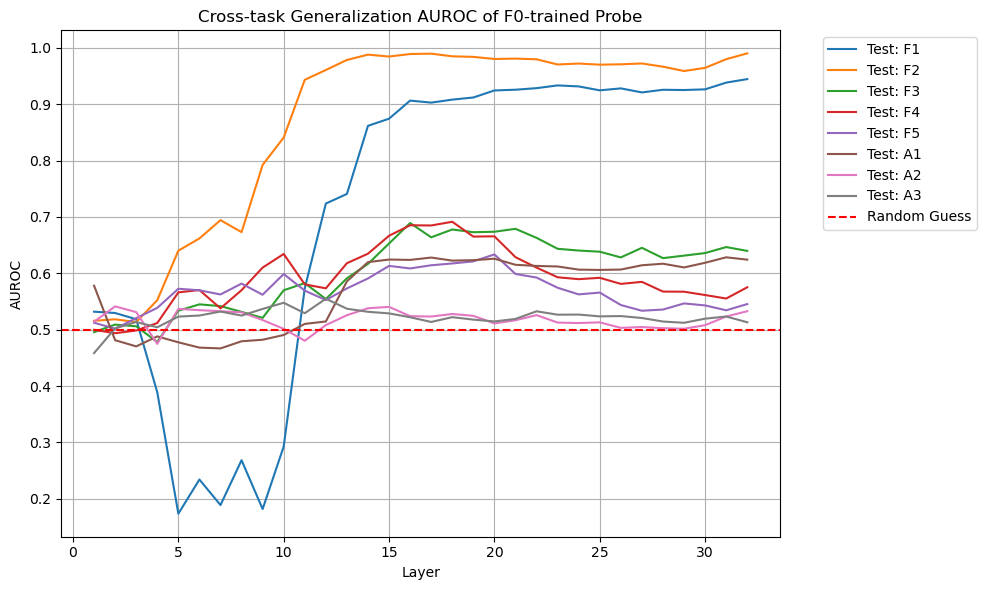

In [13]:
plt.figure(figsize=(10, 6))

for test_task, scores in auroc_results.items():
    plt.plot(range(1, num_layers + 1), scores, label=f"Test: {test_task}")

plt.title("Cross-task Generalization AUROC of F0-trained Probe")
plt.xlabel("Layer")
plt.ylabel("AUROC")
plt.axhline(y=0.5, color='r', linestyle='--', label="Random Guess")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# Replicate Figure 5: 2D Projections at Layer 25
layer_25_idx = 25 - 1 # 0-indexed

# 1. Train probe on F0 at Layer 25 to get Truth Direction
X_train_f0_l25 = activations["F0"]["train"][:, layer_25_idx, :]
y_train_f0_l25 = labels["F0"]["train"]

probe_l25 = LogisticRegression(max_iter=1000)
probe_l25.fit(X_train_f0_l25, y_train_f0_l25)

# The normal vector of the separating hyperplane
truth_direction = probe_l25.coef_[0]
truth_direction = truth_direction / np.linalg.norm(truth_direction)

# 2. Project and prepare plotting data for all tasks
projection_data = {}

for task in tasks:
    # We'll visualize the test set
    X_test_l25 = activations[task]["test"][:, layer_25_idx, :]
    y_test = labels[task]["test"]
    
    # Y-axis: Project onto Truth Direction
    # Center the data first? The paper projects directly, but PCA requires centering. Let's center.
    X_centered = X_test_l25 - X_test_l25.mean(axis=0)
    
    y_coords = X_centered @ truth_direction
    
    # X-axis: Max variance in orthogonal space
    # Remove the truth direction component from the data
    X_orthogonal = X_centered - np.outer(y_coords, truth_direction)
    
    # Run PCA on the orthogonal subspace
    pca = PCA(n_components=1)
    x_coords = pca.fit_transform(X_orthogonal).flatten()
    
    projection_data[task] = {
        "x": x_coords,
        "y": y_coords,
        "label": y_test
    }


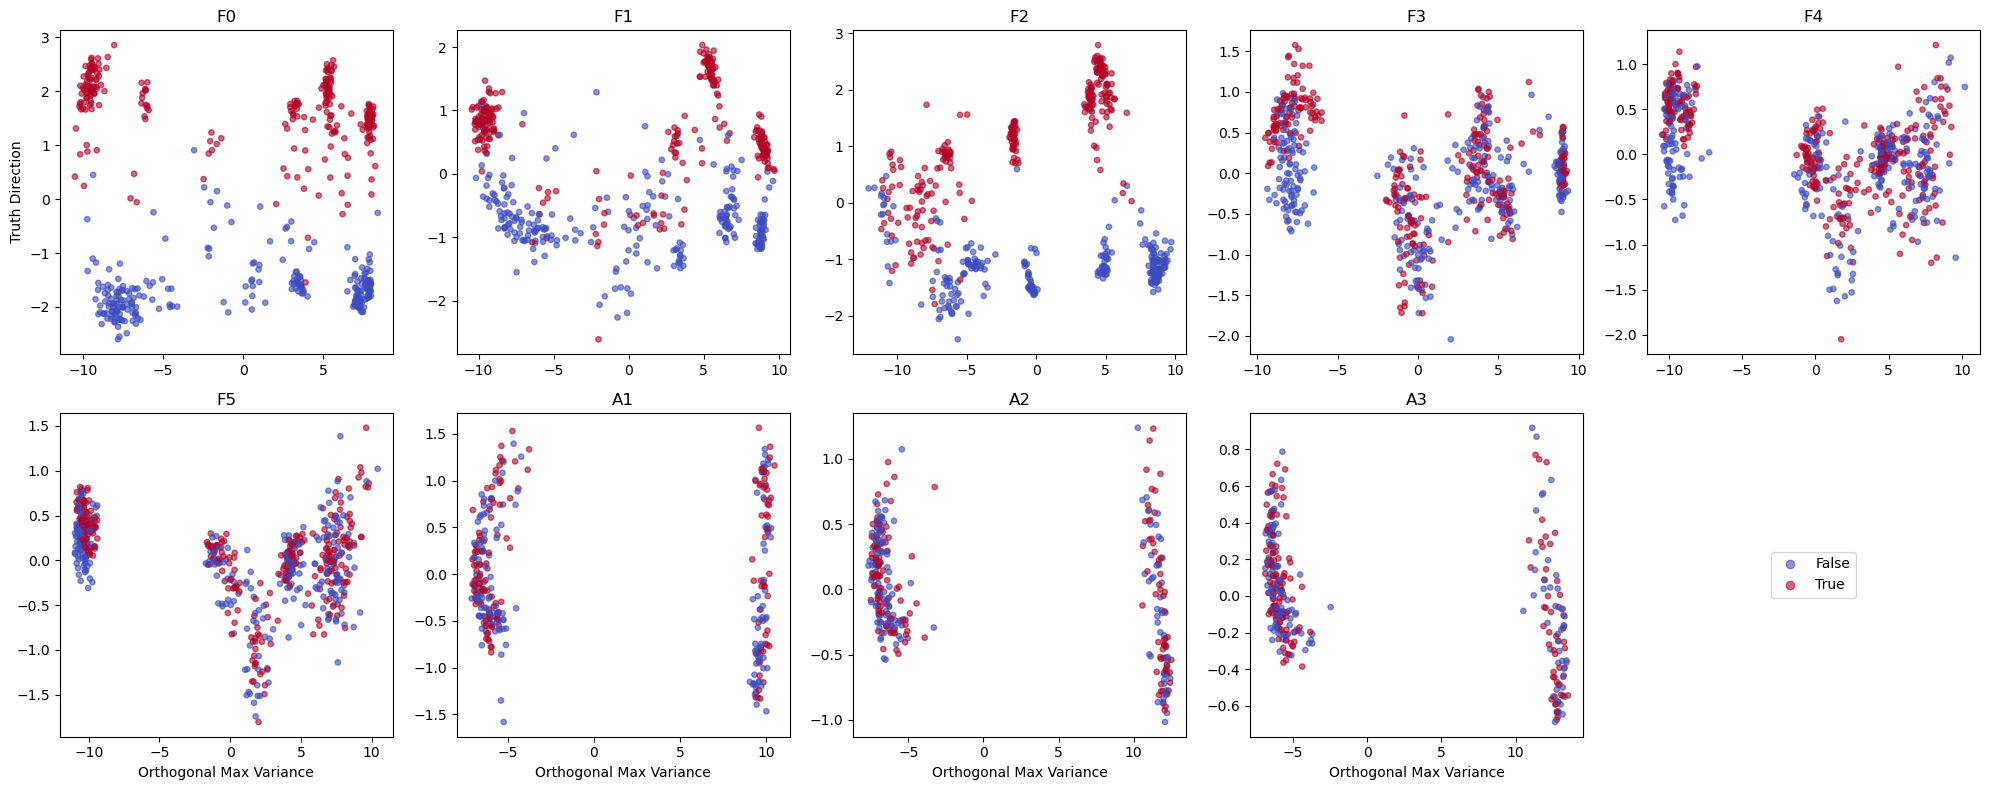

In [15]:
# Plot the 2x5 grid (assuming 10 tasks, or adjust grid size based on actual number of tasks)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Factual tasks first (F0-F5), then Arithmetic (A1-A3)
# To match the 2x5 grid closely: F0, F1, F2, F3, F4 on top; F5, A1, A2, A3 on bottom (one empty)
ordered_tasks = ["F0", "F1", "F2", "F3", "F4", "F5", "A1", "A2", "A3"]

for i, task in enumerate(ordered_tasks):
    ax = axes[i]
    data = projection_data[task]
    
    scatter = ax.scatter(data["x"], data["y"], c=data["label"], cmap='coolwarm', alpha=0.6, s=15)
    ax.set_title(task)
    
    if i == 0:
        ax.set_ylabel("Truth Direction")
    if i > 4:
        ax.set_xlabel("Orthogonal Max Variance")

# Hide the last empty subplot
if len(ordered_tasks) < len(axes):
    axes[-1].axis('off')

# Add legend to the last plot
handles, lbls = scatter.legend_elements()
axes[-1].legend(handles, ["False", "True"], loc="center")

plt.tight_layout()
plt.show()


In [16]:
import pickle

# Save the activations and labels to disk
with open('extracted_activations.pkl', 'wb') as f:
    pickle.dump(activations, f)
    
with open('extracted_labels.pkl', 'wb') as f:
    pickle.dump(labels, f)

print("Saved to disk successfully!")


Saved to disk successfully!
